In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.models import * 
from tensorflow.keras.preprocessing import image

In [ ]:
train_datagen = image.ImageDataGenerator(
    rotation_range=15,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    width_shift_range=0.1,
    height_shift_range=0.1
)
test_datagen= image.ImageDataGenerator(    rotation_range=15,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    width_shift_range=0.1,
    height_shift_range=0.1)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/Final Year Project/Dataset_1/train',
    target_size = (224,224),
    batch_size = 8,
    class_mode = 'categorical')
test_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/Final Year Project/Dataset_1/test',
    target_size = (224,224),
    batch_size = 8,
    class_mode = 'categorical')
validation_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/Final Year Project/Dataset_1/valid',
    target_size = (224,224),
    batch_size = 8,
    shuffle=True,
    class_mode = 'categorical')

Found 613 images belonging to 4 classes.
Found 315 images belonging to 4 classes.
Found 91 images belonging to 4 classes.


In [ ]:
base_model = tf.keras.applications.EfficientNetB3(weights='imagenet', input_shape=(224,224,3), include_top=False)

for layer in base_model.layers:
    layer.trainable=True
model = Sequential()
model.add(base_model)
model.add(GaussianNoise(0.25))
model.add(GlobalAveragePooling2D())
model.add(Dense(1024,activation='relu'))
model.add(BatchNormalization())
model.add(GaussianNoise(0.25))
model.add(Dropout(0.25))
model.add(Dense(4, activation='sigmoid'))
model.summary()

43941136/43941136 [==============================] - 3s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb3 (Functional)  (None, 7, 7, 1536)       10783535  
                                                                 
 gaussian_noise (GaussianNoi  (None, 7, 7, 1536)       0         
 se)                                                             
                                                                 
 global_average_pooling2d (G  (None, 1536)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 1024)              1573888   
                                                                 
 batch_normalization (BatchN  (None, 1024)             4096      
 ormalization)                                           

In [ ]:
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
              metrics=['accuracy','AUC','Precision','Recall'])

In [ ]:
from keras.callbacks import EarlyStopping
es=EarlyStopping(monitor='val_loss',patience=3)
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=validation_generator,
    steps_per_epoch= 75
    )

Epoch 1/100
75/75 [==============================] - 403s 5s/step - loss: 1.9328 - accuracy: 0.2948 - auc: 0.5533 - precision: 0.2696 - recall: 0.5595 - val_loss: 1.3090 - val_accuracy: 0.3626 - val_auc: 0.6449 - val_precision: 0.3403 - val_recall: 0.5385
Epoch 2/100
75/75 [==============================] - 20s 260ms/step - loss: 1.5484 - accuracy: 0.4171 - auc: 0.6483 - precision: 0.3285 - recall: 0.6432 - val_loss: 1.2531 - val_accuracy: 0.3956 - val_auc: 0.6803 - val_precision: 0.3526 - val_recall: 0.6703
Epoch 3/100
75/75 [==============================] - 17s 219ms/step - loss: 1.4044 - accuracy: 0.4707 - auc: 0.7081 - precision: 0.3645 - recall: 0.7119 - val_loss: 1.3559 - val_accuracy: 0.3626 - val_auc: 0.6308 - val_precision: 0.3235 - val_recall: 0.6044
Epoch 4/100
75/75 [==============================] - 17s 231ms/step - loss: 1.2821 - accuracy: 0.5109 - auc: 0.7405 - precision: 0.3811 - recall: 0.7571 - val_loss: 1.4575 - val_accuracy: 0.3407 - val_auc: 0.6203 - val_precision

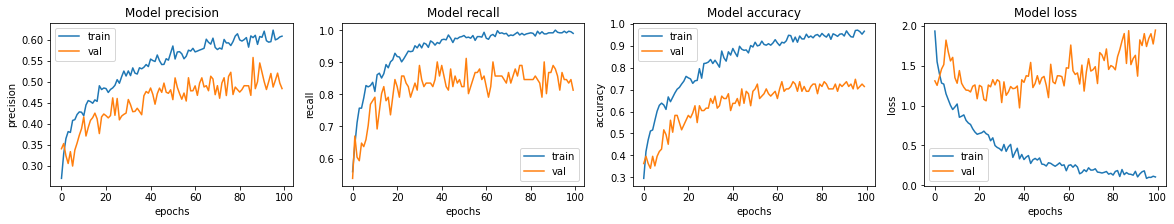

In [ ]:
fig,ax=plt.subplots(1,4,figsize=(20,3))
ax=ax.ravel()
for i,met in enumerate(['precision','recall','accuracy','loss']):
  ax[i].plot(history.history[met])
  ax[i].plot(history.history['val_'+met])
  ax[i].set_title('Model {}'.format(met))
  ax[i].set_xlabel('epochs')
  ax[i].set_ylabel(met)
  ax[i].legend(['train', 'val'])

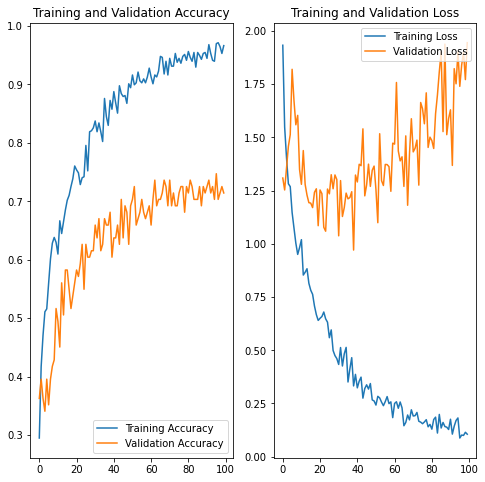

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(100)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
model.evaluate(train_generator)

77/77 [==============================] - 11s 139ms/step - loss: 0.0121 - accuracy: 0.9967 - auc: 0.9996 - precision: 0.7503 - recall: 1.0000


[0.01212927233427763,
 0.9967373609542847,
 0.9995608329772949,
 0.7503060102462769,
 1.0]

In [ ]:
model.evaluate(test_generator)

40/40 [==============================] - 217s 6s/step - loss: 0.3842 - accuracy: 0.9016 - auc: 0.9704 - precision: 0.5757 - recall: 0.9778


[0.3841574490070343,
 0.9015873074531555,
 0.9704425930976868,
 0.5757009387016296,
 0.9777777791023254]

In [ ]:
model.evaluate(validation_generator)

12/12 [==============================] - 2s 129ms/step - loss: 2.0475 - accuracy: 0.7363 - auc: 0.8702 - precision: 0.5203 - recall: 0.8462


[2.0475432872772217,
 0.7362637519836426,
 0.8702250123023987,
 0.5202702879905701,
 0.8461538553237915]

In [ ]:
model.save('/content/drive/MyDrive/Colab Notebooks/Final Year Project/EfficientNetB3.h5',model)

In [ ]:
mymodel=load_model('/content/drive/MyDrive/Colab Notebooks/Final Year Project/EfficientNetB3.h5')

In [ ]:
mymodel.evaluate(train_generator)

77/77 [==============================] - 13s 141ms/step - loss: 0.0125 - accuracy: 0.9984 - auc: 0.9995 - precision: 0.7577 - recall: 1.0000


[0.01252121664583683,
 0.9983686804771423,
 0.999458909034729,
 0.7577255964279175,
 1.0]

In [ ]:
mymodel.evaluate(test_generator)

40/40 [==============================] - 6s 139ms/step - loss: 0.3224 - accuracy: 0.8952 - auc: 0.9718 - precision: 0.5474 - recall: 0.9714


[0.32237115502357483,
 0.8952381014823914,
 0.9717695713043213,
 0.5474060773849487,
 0.9714285731315613]

In [ ]:
mymodel.evaluate(validation_generator)

12/12 [==============================] - 2s 131ms/step - loss: 1.7828 - accuracy: 0.7363 - auc: 0.8782 - precision: 0.5302 - recall: 0.8681


[1.7828288078308105,
 0.7362637519836426,
 0.8782151341438293,
 0.5302013158798218,
 0.8681318759918213]

1/1 [==============================] - 3s 3s/step
[[0.22290322 0.04368863 0.0361404  0.99998105]]
THE UPLOADED IMAGE IS SUSPECTED AS: squamous cell carcinoma


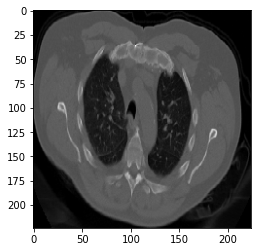

In [ ]:
from keras.preprocessing import image
img = tf.keras.utils.load_img('/content/drive/MyDrive/Colab Notebooks/Final Year Project/Dataset_1/valid/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/000117 (4).png',target_size=(224,224))
imag = tf.keras.utils.img_to_array(img)
imaga = np.expand_dims(imag,axis=0) 
ypred = model.predict(imaga)
print(ypred)
a=np.argmax(ypred,-1)
if a==0:
  op="Adenocarcinoma"
elif a==1:
  op="large cell carcinoma"
elif a==2:
  op="normal (void of cancer)"
else:
  op="squamous cell carcinoma"    
plt.imshow(img)
print("THE UPLOADED IMAGE IS SUSPECTED AS: "+str(op))  
